## Set parameters

In [217]:
smoothing_size = 1 # make 100
extension_factor = 1.1; 
step_size = 2;
max_width = 2048
overlap_threshold = 0.3
weight_epithelium_coverage = 0.8
weight_background_pixels = 0.2

slice_name = "h&e_unknown_case106_match1.tif"
slice_detail = "h&e_unknown_case106_match1"
mask_name = slice_detail + ".png"
patched_slice_name = "output/patched_" + mask_name
metrics_file_name = "output/metrics_before_improvement_" + slice_detail + ".csv"
patch_length_filename = "output/patch_lengths_before_improvement" + slice_detail + ".csv"

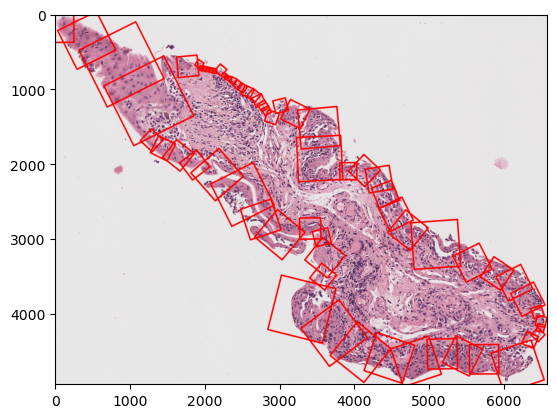

In [218]:
# Loading libraries and functions

import numpy as np
import cv2
from shapely.geometry import Polygon
import matplotlib.pyplot as plt
from sklearn.model_selection import ParameterGrid
from matplotlib import colors
import pandas as pd
import csv

# Function to draw patches
def draw_patches(image, patch_list, color = [255,0,0], thickness = 20):
    patches_on_slice = image.copy()
    for contour_patches in patch_list:
        for patch in contour_patches:
            points = patch.astype(np.int32)
            cv2.polylines(patches_on_slice, [points], isClosed = True, color = color, thickness = thickness)        
    return patches_on_slice

# Function to calculate patch overlap
def patch_overlap(square1,square2):

    square1 = Polygon(square1)
    square2 = Polygon(square2)

    if not square1.intersects(square2):
        return 0
    
    intersection_area = square1.intersection(square2).area
    smallest_area = min(square1.area,square2.area)
    return intersection_area/smallest_area

# Reading data
tissue_slice = cv2.cvtColor(cv2.imread("cases/" + slice_name), cv2.COLOR_BGR2RGB)
epithelium_mask = cv2.cvtColor(cv2.imread("cases/" + mask_name), cv2.COLOR_BGR2RGB)
epithelium_mask_gray = cv2.cvtColor(epithelium_mask, cv2.COLOR_RGB2GRAY)
Otsu_threshold, epithelium_mask_2D = cv2.threshold(epithelium_mask_gray, 0, 255, 
                            cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

# Getting contours
contours, hierarchy = cv2.findContours(epithelium_mask_2D, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

# Getting tangents and normals on contour points
all_normals=[]
all_tangents = []

for contour in contours:

    contour_points = contour.reshape(-1,2)
    num_contour_points = len(contour_points)
    tangents = np.zeros_like(contour_points, dtype = float)

    for i in range(num_contour_points):
        
        prev_idx = (i - smoothing_size) % num_contour_points 
        
        next_idx = (i + smoothing_size) % num_contour_points 
        
        tangent = contour_points[next_idx] - contour_points[prev_idx]
        
        tangent = tangent / (np.linalg.norm(tangent) + 1e-8)
        tangents[i] = tangent            

    normals = np.zeros_like(tangents)
    normals[:,0] = -tangents[:,1]
    normals[:,1] = tangents[:,0]
    
    all_normals.append(normals)
    all_tangents.append(tangents)
    
all_patches = []
all_patch_lengths = []
height, width = epithelium_mask_2D.shape

# Finding patch corners on each contour
for c in range(len(contours)):
    contour_points = contours[c].reshape(-1, 2)
    contour_normals = all_normals[c]
    contour_tangents = all_tangents[c]
    contour_patch_lengths = []
    squares = []
    
    for i, point in enumerate(contour_points):
        point = point.astype(int)

        steps = np.arange(0, max_width, step_size)[:, None]
        normal_points = np.clip(point - steps * contour_normals[i], 0, [width - 1, height - 1]).astype(int)

        pixel_values = epithelium_mask_2D[normal_points[:, 1], normal_points[:, 0]]

        stop = np.where(pixel_values == 0)[0]

        epithelium_width = stop[0] * step_size if stop.size > 0 else max_width

        patch_length = int(epithelium_width * extension_factor)
        half_patch_length = patch_length // 2 

        corners = np.array([
            point + (contour_tangents[i] * half_patch_length),
            point - (contour_tangents[i] * half_patch_length),
            point - (contour_tangents[i] * half_patch_length) - (contour_normals[i] * patch_length),
            point + (contour_tangents[i] * half_patch_length) - (contour_normals[i] * patch_length)
        ])
        squares.append(corners)
        contour_patch_lengths.append(patch_length)
    all_patches.append(squares)
    all_patch_lengths.append(contour_patch_lengths)

all_selected_patches = []
all_selected_patch_lengths = []

# Removing highly overlapping contours
for c in range(len(contours)):
    contour_points = contours[c].reshape(-1, 2)
    
    selected_patches = []
    selected_patch_lengths = []
    for i, point in enumerate(contour_points):
        current_patch = all_patches[c][i]
        current_patch_length = all_patch_lengths[c][i]
        if not any(patch_overlap(current_patch, ith_selected_patch) > overlap_threshold \
                 for ith_selected_patch in selected_patches):
            selected_patches.append(current_patch)
            selected_patch_lengths.append(current_patch_length)
    all_selected_patches.append(selected_patches)
    all_selected_patch_lengths.append(selected_patch_lengths)

selected_patches_on_slice = draw_patches(tissue_slice, all_selected_patches)

# Exporting patched slice
cv2.imwrite(patched_slice_name, cv2.cvtColor(selected_patches_on_slice, cv2.COLOR_RGB2BGR))

# Calculating performance metrics
total_epithelium_pixels = (epithelium_mask_2D > 0).sum()
patch_mask = np.zeros_like(epithelium_mask_2D, dtype=np.uint8)

#For all patches in all contours, use them to create a mask
for contour_patches in all_selected_patches:
    for patch in contour_patches:
        patch = np.array(patch,dtype = np.int32).reshape(-1, 1, 2)
        cv2.fillPoly(patch_mask, [patch], 255)

number_of_patch_mask_pixels = np.count_nonzero(patch_mask > 0)

covered_epithelium_pixels = np.count_nonzero((patch_mask > 0) & (epithelium_mask_2D > 0))
covered_background_pixels = np.count_nonzero((patch_mask > 0) & (epithelium_mask_2D == 0))

total_epithelium_coverage = (covered_epithelium_pixels / total_epithelium_pixels*100)
background_pixel_percent = (covered_background_pixels / number_of_patch_mask_pixels*100)
score = weight_epithelium_coverage*total_epithelium_coverage + weight_background_pixels*(100 - background_pixel_percent)

# Exporting performance metrics and parameter values
metrics = pd.DataFrame({'Metric':['total_epithelium_coverage', 'background_pixel_percent',
                       'score', 'smoothing_size', 'extension_factor', 'step_size',
                       'max_width', 'overlap_threshold'], 
              'Value':[total_epithelium_coverage, background_pixel_percent, score, 
                      smoothing_size, extension_factor, step_size, max_width, overlap_threshold]})

metrics.to_csv(metrics_file_name, index=False)

# Exporting patch lengths
max_length = max(len(contour_patch_lengths) for contour_patch_lengths in all_selected_patch_lengths)

padded_list = [contour_patch_lengths + [''] * (max_length - len(contour_patch_lengths)) \
               for contour_patch_lengths in all_selected_patch_lengths]

transposed_list = list(map(list, zip(*padded_list)))

with open(patch_length_filename, mode='w', newline='') as file:
    writer = csv.writer(file)
    writer.writerows(transposed_list)

plt.imshow(selected_patches_on_slice);

In [219]:
print(f"Total Coverage: {total_epithelium_coverage:.2f}%")
print(f"Background Pixel Percentage: {background_pixel_percent:.2f}%")
print(f"Score Percentage: {score:.2f}%")

Total Coverage: 96.25%
Background Pixel Percentage: 20.26%
Score Percentage: 92.95%


## Exporting the patches as images

### Step 1: Add a padding around the image if there are any patch corners that currently lie outside image bounds

In [220]:
all_points = np.vstack(all_selected_patches[0])

# Find the smallest and largest x and y values
min_x = np.min(all_points[:, 0])
max_x = np.max(all_points[:, 0])
min_y = np.min(all_points[:, 1])
max_y = np.max(all_points[:, 1])

print(f"Smallest x: {min_x}")
print(f"Largest x: {max_x}")
print(f"Smallest y: {min_y}")
print(f"Largest y: {max_y}")

Smallest x: -128.99604589681874
Largest x: 6570.139781028489
Smallest y: -35.978914085951374
Largest y: 5066.580005909194


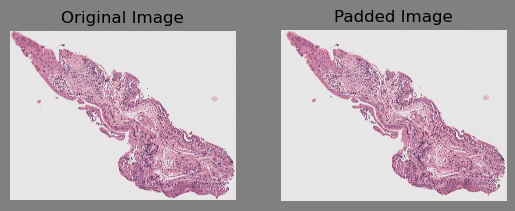

In [221]:
import math
import numpy as np
import matplotlib.pyplot as plt

def add_padding(image):
    
    height, width, channels = image.shape

    if min_x < 0:
        left = math.ceil(np.abs(min_x))
    else:
        left = 0

    if max_x > width:
        right = math.ceil(max_x - width)
    else:
        right = 0

    if min_y < 0:
        top = math.ceil(np.abs(min_y))
    else:
        top = 0

    if max_y > height:
        bottom = math.ceil(max_y - height)
    else:
        bottom = 0

    new_width = width + right + left
    new_height = height + top + bottom

    # Compute the padding color using the mode (most frequent pixel value)
    threshold = 150
    mask = np.all(image > threshold, axis=-1)
    if np.any(mask):
        bright_pixels = image[mask]
        # Use a fast mode computation if the image dtype is integer (uint8)
        if np.issubdtype(image.dtype, np.integer):
            # Create dimensions for each channel (e.g., 256 for uint8)
            dims = (np.iinfo(image.dtype).max + 1,) * channels
            # Convert each pixel (row) into a unique integer identifier
            combined = np.ravel_multi_index(bright_pixels.T, dims)
            unique_vals, counts = np.unique(combined, return_counts=True)
            mode_val = unique_vals[np.argmax(counts)]
            # Convert the unique integer back to the multi-channel pixel value
            mode_color = np.array(np.unravel_index(mode_val, dims)).astype(image.dtype)
            pad_color = mode_color.flatten()
        else:
            # Fallback for non-integer types
            pixels, counts = np.unique(bright_pixels, axis=0, return_counts=True)
            pad_color = pixels[np.argmax(counts)]
    else:
        pad_color = np.array([threshold] * channels, dtype=image.dtype)

    # Create a new image filled with the mode padding color
    padded_image = np.ones((new_height, new_width, channels), dtype=image.dtype) * pad_color

    # Insert the original image into the array of updated dimensions
    padded_image[top:top + height, left:left + width] = image

    # Display the images side by side
    fig, axes = plt.subplots(1, 2, facecolor='gray')
    axes[0].imshow(image)
    axes[0].set_title("Original Image")
    axes[0].axis("off")
    axes[1].imshow(padded_image)
    axes[1].set_title("Padded Image")
    axes[1].axis("off")
    plt.show()

    return padded_image, right, left, top, bottom

padded_image,right, left, top, bottom = add_padding(tissue_slice)


In [222]:
# Create shift array and shift the patches by the same amount as the padding added
shift_x = left
shift_y = top
shift_array = np.array([shift_x, shift_y])
shifted_points = all_points + shift_array
    
shifted_points = np.split(shifted_points, len(shifted_points) // 4)
shifted_points = [shifted_points]   

In [223]:
shifted_patches_on_slice = draw_patches(padded_image, shifted_points)

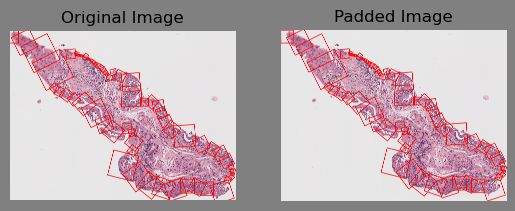

In [224]:
# Display the images side by side
fig, axes = plt.subplots(1, 2, facecolor = 'gray')
axes[0].imshow(selected_patches_on_slice)
axes[0].set_title("Original Image")
axes[0].axis("off")
axes[1].imshow(shifted_patches_on_slice)
axes[1].set_title("Padded Image")
axes[1].axis("off")
plt.show()

In [225]:
# run this block to make sure that all values are within image bounds now

shifted_points_stacked = np.vstack(shifted_points[0])

min_x = np.min(shifted_points_stacked[:, 0])
max_x = np.max(shifted_points_stacked[:, 0])
min_y = np.min(shifted_points_stacked[:, 1])
max_y = np.max(shifted_points_stacked[:, 1])

print(f"Smallest x: {min_x}")
print(f"Largest x: {max_x}")
print(f"Smallest y: {min_y}")
print(f"Largest y: {max_y}")

Smallest x: 0.003954103181257551
Largest x: 6699.139781028489
Smallest y: 0.021085914048626364
Largest y: 5102.580005909194


### Step 2: Use cv2.fillpoly() to make a mask of each patch
### Step 3: Apply the mask to the tissue image using cv2.bitwise_and
### Step 4: Crop the image around the patch
### Step 5: Rotate the patch to be parallel to the axis

In [226]:
def extract_square_images(image, squares):
    
    patches = []
    square_list = squares[0]

    for square in square_list:

        # create an empty mask with white inside just the square's region
        square = square.astype(np.int32)
        square.reshape((-1,1,2)) # bc cv2.fillpoly expects points to be in shape (N,1,2)
        mask = np.zeros(image.shape[:2],dtype = np.uint8)
        cv2.fillPoly(mask, [square], 255)

        # Apply the mask to the image
        masked_image = cv2.bitwise_and(image, image, mask = mask)

        # uncomment to see placement of patch within the entire slice image 
        # plt.imshow(masked_image)
        # plt.show()

        # Crop the image around the rotated square (will have black space due to rotation)
        x_min = np.min(square[:, 0])
        x_max = np.max(square[:, 0])
        y_min = np.min(square[:, 1])
        y_max = np.max(square[:, 1])
        cropped_image = masked_image[y_min:y_max, x_min:x_max]

        # rotate the cropped image to be parallel to the xy axis
        # calculate the angle the patch needs to be rotated by
        point1 = square[0]  # top-left corner
        point2 = square[1]  # top-right corner
        vector = point2 - point1
        angle_degrees = np.arctan2(vector[1], vector[0]) * (180.0 / np.pi) - 180

        # Get the center of the cropped image
        center = (int((x_max - x_min)) // 2, int((y_max - y_min)) // 2)

        # Create the rotation matrix to rotate around the center
        rotation_matrix = cv2.getRotationMatrix2D(center, angle_degrees, 1.0) # 1.0 means image wont be scaled

        # Rotate the cropped image to make it parallel to xy axis
        rotated_patch = cv2.warpAffine(cropped_image, 
                                       rotation_matrix,
                                       (cropped_image.shape[1], cropped_image.shape[0])) # output image size

        # uncomment to display the plain extracted and rotated extracted patches for debugging
        # plt.subplot(1, 2, 1)
        # plt.imshow(cropped_image)
        # plt.title("Patch")
        # plt.axis('off')

        # plt.subplot(1, 2, 2)
        # plt.imshow(rotated_patch)
        # plt.title("Patch Aligned to XY Axis")
        # plt.axis('off')
        # plt.show()

        # remove the extra black pixels around the edges
        gray = cv2.cvtColor(rotated_patch, cv2.COLOR_BGR2GRAY)
        _, thresh = cv2.threshold(gray, 1, 255, cv2.THRESH_BINARY)
        contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        x, y, w, h = cv2.boundingRect(contours[0])
        cropped_img = rotated_patch[y:y+h, x:x+w]

        patches.append(cropped_img)
    
    return patches

In [227]:
patches = extract_square_images(padded_image, shifted_points)

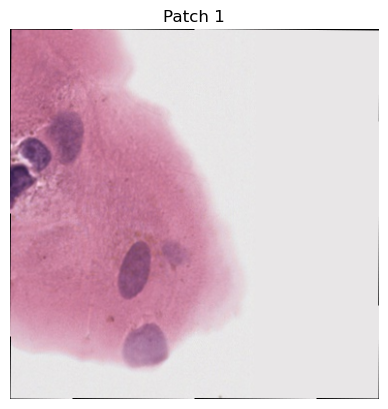

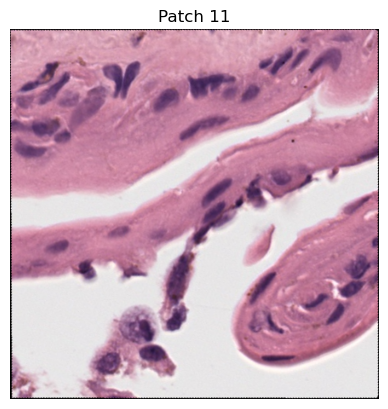

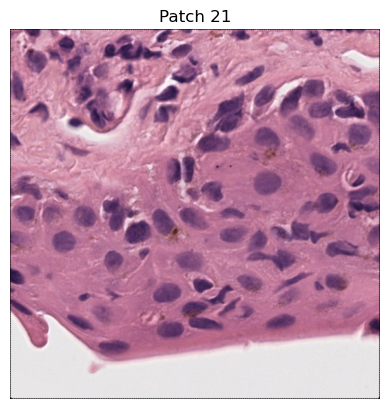

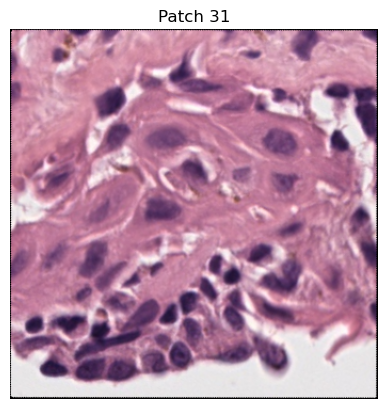

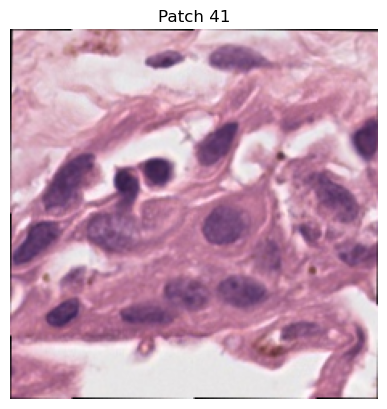

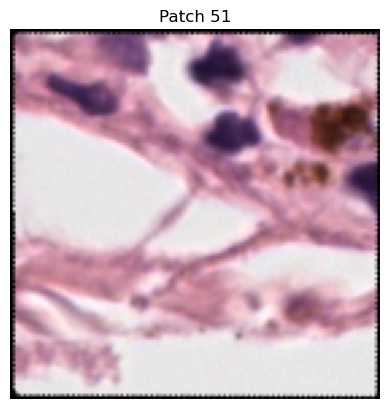

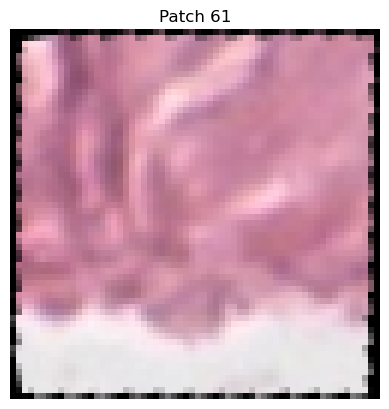

In [228]:
# Print some example patches to make sure they look right
for i, patch in enumerate(patches):
    if i % 10 == 0:
        plt.figure()
        plt.imshow(patch)
        plt.title(f"Patch {i + 1}")
        plt.axis('off')
        plt.show()

In [229]:
import os

def export_patches(patches, output_folder, prefix="patch"):
    
    # make output folder if it doesn't already exist
    os.makedirs(output_folder, exist_ok=True)
    
    # export patch as an image
    for i, patch in enumerate(patches):

        # filename for each patch
        filename = f"{prefix}_{i+1}.png" # can change to also include the slice name
        filepath = os.path.join(output_folder, filename)
        
        cv2.imwrite(filepath, patch)

In [230]:
export_patches(patches, output_folder = "patches_output")